In [ ]:
import os
import torch
from PIL import Image

from models.cnn_model import CNN_Model
from utils import get_device, build_cnn_transform,ResizeKeepRatioPad

# Parameters

In [11]:
ckpt_path = '../checkpoints/cnn_checkpoint.pt'
image_path = '../data/face/predict/'
formats = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff", ".webp"}

# Import Predict data

In [12]:
device = get_device()

## Get saved training checkpoint

In [13]:
with open(ckpt_path, 'rb') as f:
    checkpoint = torch.load(f, map_location=device)

if not isinstance(checkpoint, dict):
    raise ValueError(
        "Checkpoint must be a dict with model_state_dict, model_config, preprocess_config, and class_names. "
        "Please retrain and save checkpoint_data in training."
    )

required_keys = {"model_state_dict", "model_config", "preprocess_config", "class_names"}
missing_keys = required_keys - set(checkpoint.keys())
if missing_keys:
    raise ValueError(
        f"Checkpoint is missing required keys: {sorted(missing_keys)}. "
        "Please retrain and save checkpoint_data in training."
    )

## get config and model from checkpoint

In [14]:
model_state_dict = checkpoint["model_state_dict"]
model_config = checkpoint["model_config"]
preprocess_config = checkpoint["preprocess_config"]
class_names = checkpoint["class_names"]
input_size = model_config['input_size']

print(f'Input Size - {input_size}')

## Build model and transformer

In [15]:
model = CNN_Model(**model_config).to(device)
transform = build_cnn_transform(preprocess_config)

In [ ]:
model.load_state_dict(model_state_dict)
_ = model.eval()

# Load model and configs

In [26]:
resized_images = []

for i in os.listdir(image_path):

    path = image_path + '/' + i

    ext = os.path.splitext(i)[-1]

    if ext in formats:
        
        img = Image.open(path)
        resizer = ResizeKeepRatioPad( input_size )

        resized_img = resizer(img)

        
        resized_images.append( ( resized_img , i ))       


# Prediction

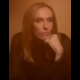

Incorrect!! - label: David-Beckham, actual : unknown, confidence: 0.2981


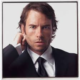

Incorrect!! - label: Usain-Bolt, actual : unknown, confidence: 0.7883


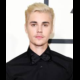

Correct!! - label: Justin-Bieber, actual : Justin-Bieber, confidence: 0.9637


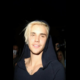

Correct!! - label: Justin-Bieber, actual : Justin-Bieber, confidence: 0.4164


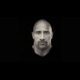

Incorrect!! - label: Usain-Bolt, actual : unknown, confidence: 0.3552


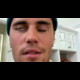

Correct!! - label: Justin-Bieber, actual : Justin-Bieber, confidence: 0.6316


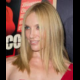

Incorrect!! - label: Ariana-Grande, actual : unknown, confidence: 0.8645


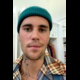

Incorrect!! - label: Cristiano-Ronaldo, actual : Justin-Bieber, confidence: 0.9567
Failed to predict - unknown


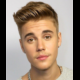

Correct!! - label: Justin-Bieber, actual : Justin-Bieber, confidence: 0.6858


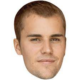

Incorrect!! - label: Ariana-Grande, actual : Justin-Bieber, confidence: 0.5213


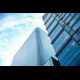

Incorrect!! - label: Usain-Bolt, actual : unknown, confidence: 0.8888


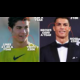

Correct!! - label: Cristiano-Ronaldo, actual : Cristiano-Ronaldo, confidence: 0.5602


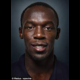

Correct!! - label: Usain-Bolt, actual : Usain-Bolt, confidence: 0.4905


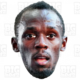

Correct!! - label: Usain-Bolt, actual : Usain-Bolt, confidence: 0.9353


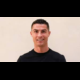

Incorrect!! - label: Justin-Bieber, actual : Cristiano-Ronaldo, confidence: 0.5163


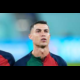

Incorrect!! - label: Usain-Bolt, actual : Cristiano-Ronaldo, confidence: 0.6011


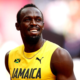

Correct!! - label: Usain-Bolt, actual : Usain-Bolt, confidence: 0.5496


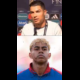

Incorrect!! - label: Usain-Bolt, actual : Cristiano-Ronaldo, confidence: 0.9380


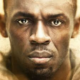

Correct!! - label: Usain-Bolt, actual : Usain-Bolt, confidence: 0.4320


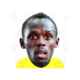

Incorrect!! - label: Ariana-Grande, actual : Usain-Bolt, confidence: 0.4366


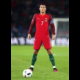

Incorrect!! - label: Usain-Bolt, actual : Cristiano-Ronaldo, confidence: 0.6696


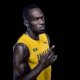

Correct!! - label: Usain-Bolt, actual : Usain-Bolt, confidence: 0.6748


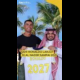

Incorrect!! - label: Usain-Bolt, actual : Cristiano-Ronaldo, confidence: 0.9367


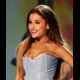

Correct!! - label: Ariana-Grande, actual : Ariana-Grande, confidence: 0.4756


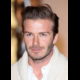

Incorrect!! - label: Justin-Bieber, actual : David-Beckham, confidence: 0.7182


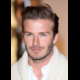

Incorrect!! - label: Justin-Bieber, actual : David-Beckham, confidence: 0.7139


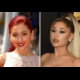

Incorrect!! - label: Usain-Bolt, actual : Ariana-Grande, confidence: 0.4107


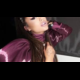

Incorrect!! - label: Cristiano-Ronaldo, actual : Ariana-Grande, confidence: 0.7667


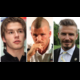

Incorrect!! - label: Cristiano-Ronaldo, actual : David-Beckham, confidence: 0.7876


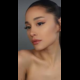

Incorrect!! - label: Cristiano-Ronaldo, actual : Ariana-Grande, confidence: 0.2350


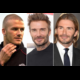

Correct!! - label: David-Beckham, actual : David-Beckham, confidence: 0.9920


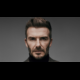

Incorrect!! - label: Cristiano-Ronaldo, actual : David-Beckham, confidence: 0.3275


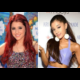

Correct!! - label: Ariana-Grande, actual : Ariana-Grande, confidence: 0.7713


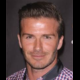

Incorrect!! - label: Justin-Bieber, actual : David-Beckham, confidence: 0.5950


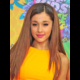

Correct!! - label: Ariana-Grande, actual : Ariana-Grande, confidence: 0.6360


In [34]:
predicted_labels = []

for item, name in resized_images:

    try:

        pic_name = name.split('-')
        del pic_name[-1]

        pic_name = '-'.join(pic_name)
        
        x = transform(item).unsqueeze(0).to(device)
    
        with torch.no_grad():
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            pred_idx = probs.argmax(dim=1).item()
            confidence = probs[0, pred_idx].item()
    
        pred_label = class_names[pred_idx]
        predicted_labels.append(pred_label)
    
        display(item)


        Result = 'Correct' if pred_label == pic_name else 'Incorrect'
    
        print(f"{Result}!! - label: {pred_label}, actual : {pic_name}, confidence: {confidence:.4f}")

    except:

        print(f'Failed to predict - {pic_name}') 